In [1]:
import pandas as pd
import numpy as np
import cv2 as cv
import os
import  matplotlib.pyplot as plt

Upload the Dataset in zip format

In [2]:
from google.colab import files
import zipfile

uploaded = files.upload()  # upload your Standardized_Control_Dataset.zip here

for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname) as z:
            z.extractall('textile_dataset')
        print(f"Extracted {fname}")

Saving Control_Data (2).zip to Control_Data (2).zip
Extracted Control_Data (2).zip


In [3]:
wallpaper_augmentations = {
    'pmm': ['flip_h', 'flip_v', 'rot_180', 'brightness', 'contrast'],
    'pm':  ['flip_h', 'flip_v', 'brightness', 'contrast'],
    'p1':  ['brightness', 'contrast'],
    'p4m': ['flip_h', 'flip_v', 'flip_d', 'rot_90', 'rot_180', 'rot_270', 'brightness', 'contrast'],
    'pg':  ['rot_180', 'brightness', 'contrast'],
    'p2':  ['rot_180', 'brightness', 'contrast'],
}

In [4]:
safe_defaults = ['brightness', 'contrast']

remaining_groups = [
    'p3', 'p3m1', 'p31m',   # 3-fold rotation groups
    'p4', 'p4g',              # 4-fold without full mirrors
    'p6', 'p6m',              # 6-fold rotation groups
    'p2mm', 'cmm', 'pmg', 'pgg'  # remaining reflection groups
]

for group in remaining_groups:
    wallpaper_augmentations[group] = safe_defaults

In [5]:
print(f"Total groups covered: {len(wallpaper_augmentations)}")
for group, transforms in wallpaper_augmentations.items():
    print(f"  {group:6s} → {transforms}")

Total groups covered: 17
  pmm    → ['flip_h', 'flip_v', 'rot_180', 'brightness', 'contrast']
  pm     → ['flip_h', 'flip_v', 'brightness', 'contrast']
  p1     → ['brightness', 'contrast']
  p4m    → ['flip_h', 'flip_v', 'flip_d', 'rot_90', 'rot_180', 'rot_270', 'brightness', 'contrast']
  pg     → ['rot_180', 'brightness', 'contrast']
  p2     → ['rot_180', 'brightness', 'contrast']
  p3     → ['brightness', 'contrast']
  p3m1   → ['brightness', 'contrast']
  p31m   → ['brightness', 'contrast']
  p4     → ['brightness', 'contrast']
  p4g    → ['brightness', 'contrast']
  p6     → ['brightness', 'contrast']
  p6m    → ['brightness', 'contrast']
  p2mm   → ['brightness', 'contrast']
  cmm    → ['brightness', 'contrast']
  pmg    → ['brightness', 'contrast']
  pgg    → ['brightness', 'contrast']


Upload CSV Obtained from the Classifier

In [6]:
from google.colab import files

uploaded = files.upload()

Saving upgraded_results.csv to upgraded_results.csv


In [7]:
# Load the results CSV that your upgraded classifier already produced
df = pd.read_csv('upgraded_results.csv')

# Build a list of (full_image_path, wallpaper_group) tuples
image_data = []

for _, row in df.iterrows():
    full_path = os.path.join('textile_dataset', 'Control_Data',
                              row['true_label'], row['filename'])
    group = row['wallpaper_group']
    image_data.append((full_path, group))

# Sanity check
for path, group in image_data[:5]:
    print(f"{group:6s} → {path}")

pgg    → textile_dataset/Control_Data/manipuriphanke/image9_12.jpg
pmm    → textile_dataset/Control_Data/manipuriphanke/image9_7.jpg
p1     → textile_dataset/Control_Data/manipuriphanke/image9_11.jpg
pg     → textile_dataset/Control_Data/manipuriphanke/image9_2.jpg
pm     → textile_dataset/Control_Data/manipuriphanke/image9_4.jpg


In [8]:
def apply_flip(image, direction):
  if direction == 'flip_h':
      image = cv.flip(image,1)

  elif direction == 'flip_v':
       image = cv.flip(image,0)

  elif direction == 'flip_d':
       image = cv.transpose(image)

  return image

In [9]:
def apply_rotation(image, direction):
    # Force square so rotation doesn't create black corners
    h, w = image.shape[:2]
    size = min(h, w)
    image = cv.resize(image, (size, size))

    center = (size // 2, size // 2)

    if direction == 'rot_90':
        angle = 90
    elif direction == 'rot_180':
        angle = 180
    elif direction == 'rot_270':
        angle = 270

    M = cv.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv.warpAffine(image, M, (size, size))
    return rotated

In [47]:
def apply_colour(image, direction):
    if direction == 'brightness':
        beta = np.random.uniform(-30, 30)
        image = cv.convertScaleAbs(image, alpha=1.0, beta=beta)
    elif direction == 'contrast':
        alpha = np.random.uniform(0.85, 1.15)
        image = cv.convertScaleAbs(image, alpha=alpha, beta=0)
    return image


axes[4].imshow(cv.cvtColor(apply_colour(img, 'brightness'), cv.COLOR_BGR2RGB))
axes[5].imshow(cv.cvtColor(apply_colour(img, 'contrast'), cv.COLOR_BGR2RGB))
plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

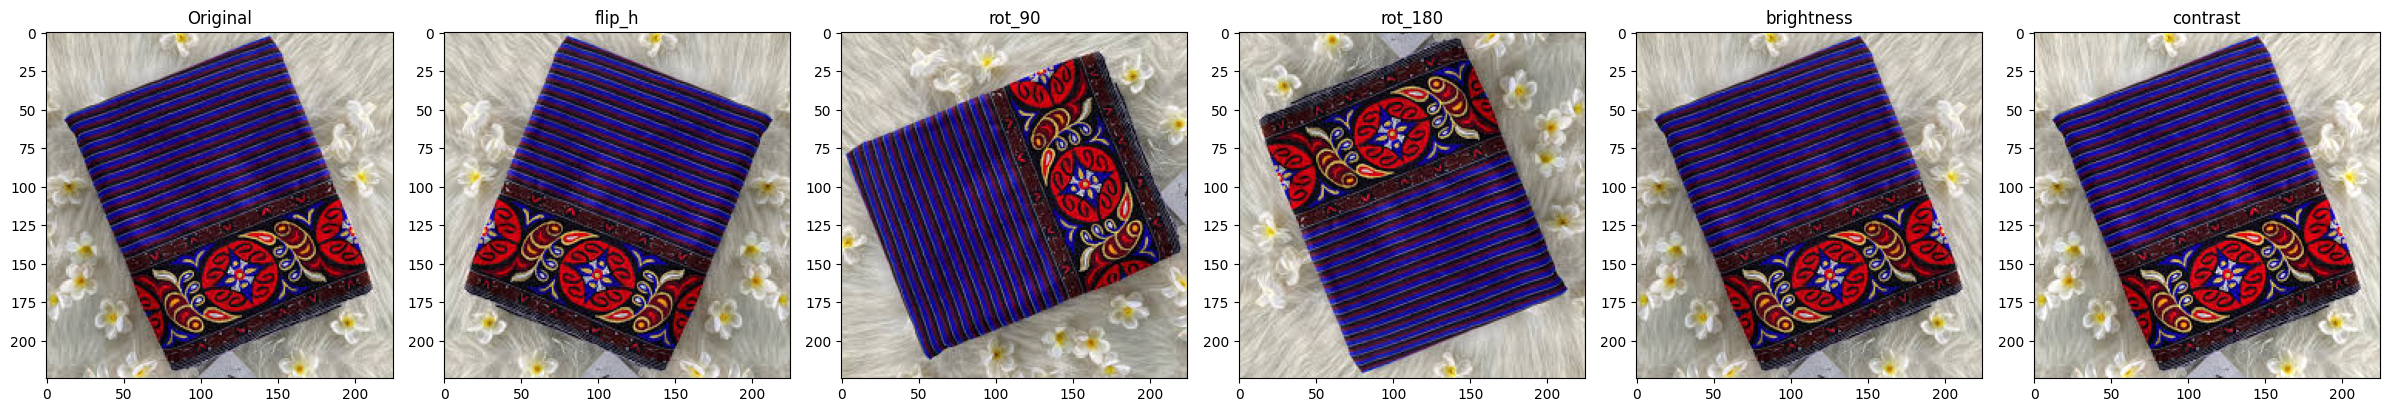

In [48]:
img = cv.imread(image_data[0][0])
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Original')
axes[1].imshow(cv.cvtColor(apply_flip(img, 'flip_h'), cv.COLOR_BGR2RGB)); axes[1].set_title('flip_h')
axes[2].imshow(cv.cvtColor(apply_rotation(img, 'rot_90'), cv.COLOR_BGR2RGB)); axes[2].set_title('rot_90')
axes[3].imshow(cv.cvtColor(apply_rotation(img, 'rot_180'), cv.COLOR_BGR2RGB)); axes[3].set_title('rot_180')
axes[4].imshow(cv.cvtColor(apply_colour(img, 'brightness'), cv.COLOR_BGR2RGB)); axes[4].set_title('brightness')
axes[5].imshow(cv.cvtColor(apply_colour(img, 'contrast'), cv.COLOR_BGR2RGB)); axes[5].set_title('contrast')
plt.tight_layout()
plt.show()

In [16]:
output_dir =  '/content/drive/MyDrive/try1'
log = []

for path, group in image_data:
    # Load image
    img = cv.imread(path)
    if img is None:
        print(f"⚠ Could not read {path}")
        continue

    # Get class label from folder name
    label = os.path.basename(os.path.dirname(path))

    # Look up allowed transforms for this wallpaper group
    allowed = wallpaper_augmentations.get(group, ['brightness', 'contrast'])

    # Apply every allowed transform
    for transform in allowed:
        if transform.startswith('flip'):
            augmented = apply_flip(img, transform)
        elif transform.startswith('rot'):
            augmented = apply_rotation(img, transform)
        elif transform in ('brightness', 'contrast'):
            augmented = apply_colour(img, transform)
        else:
            continue

        # Build save path
        filename = os.path.splitext(os.path.basename(path))[0]
        save_name = f"{filename}_{transform}.jpg"
        save_path = os.path.join(output_dir, label, save_name)

        # Save the augmented image
        cv.imwrite(save_path, augmented)

        # Log what we did
        log.append({
            'original': os.path.basename(path),
            'label': label,
            'transform': transform,
            'saved_as': save_name,
            'wallpaper_group': group
        })

# Save log to CSV
log_df = pd.DataFrame(log)
log_df.to_csv('augmentation_log.csv', index=False)

print(f"Done! Generated {len(log)} augmented images")
print(f"\nPer-class breakdown:")
for cls in sorted(log_df['label'].unique()):
    count = len(log_df[log_df['label'] == cls])
    print(f"  {cls:25s}: {count} images")

KeyboardInterrupt: 

In [17]:
from google.colab import drive
drive.mount('/content/drive')
output_dir = '/content/drive/MyDrive/try1'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
output_dir = '/content/drive/MyDrive/try1'

classes = list(set(os.path.basename(os.path.dirname(path))
                   for path, group in image_data))

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

print("Created folders:")
for cls in sorted(classes):
    print(f"  {output_dir}/{cls}/")

Created folders:
  /content/drive/MyDrive/try1/ajrakh/
  /content/drive/MyDrive/try1/bagru/
  /content/drive/MyDrive/try1/ikat/
  /content/drive/MyDrive/try1/kancheepuram_checks/
  /content/drive/MyDrive/try1/leheriya/
  /content/drive/MyDrive/try1/madrasplaids/
  /content/drive/MyDrive/try1/manipuriphanke/
  /content/drive/MyDrive/try1/mizopuan/
  /content/drive/MyDrive/try1/patola/
  /content/drive/MyDrive/try1/sanganeri/


Normalised DCGAN Implementation


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
import cv2 as cv
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [36]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, num_classes=10):
        super(Generator, self).__init__()

        self.class_embedding = nn.Embedding(num_classes, noise_dim)

        self.model = nn.Sequential(
            nn.utils.spectral_norm(nn.ConvTranspose2d(noise_dim * 2, 512, 4, 1, 0, bias=False)),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.utils.spectral_norm(nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.utils.spectral_norm(nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.utils.spectral_norm(nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.utils.spectral_norm(nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.utils.spectral_norm(nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False)),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_emb = self.class_embedding(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, label_emb], dim=1)
        return self.model(x)

In [38]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=10):
        super(Discriminator, self).__init__()

        self.class_embedding = nn.Embedding(num_classes, 128 * 128)

        self.model = nn.Sequential(
            # Input: 4 x 128 x 128
            nn.utils.spectral_norm(nn.Conv2d(4, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            nn.utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.utils.spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.utils.spectral_norm(nn.Conv2d(256, 512, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.utils.spectral_norm(nn.Conv2d(512, 1024, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.utils.spectral_norm(nn.Conv2d(1024, 1, 4, 1, 0, bias=False)),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        label_map = self.class_embedding(labels).view(-1, 1, 128, 128)
        x = torch.cat([image, label_map], dim=1)
        return self.model(x).view(-1, 1)

In [40]:
class TextileDataset(Dataset):
    def __init__(self, root_dir):
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),  # changed from 64
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    label = os.path.basename(root)
                    if label in self.class_to_idx:
                        self.image_paths.append(os.path.join(root, file))
                        self.labels.append(self.class_to_idx[label])

        print(f"Found {len(self.image_paths)} images across {len(self.classes)} classes")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

In [50]:
dataset = TextileDataset('/content/drive/MyDrive/try1')

if len(dataset) == 0:
    print("⚠ No images found. Check your dataset path.")
else:
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
    batch_images, batch_labels = next(iter(dataloader))
    print(f"Batch shape: {batch_images.shape}")

Found 593 images across 10 classes
Batch shape: torch.Size([16, 3, 128, 128])


In [43]:
# Loss function
criterion = nn.BCELoss()

# Optimizers - separate one for each network
lr = 0.0002
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# Fixed noise for visualising progress
fixed_noise = torch.randn(16, 100, 1, 1).to(device)

print("Loss function and optimizers ready")

Loss function and optimizers ready


In [49]:
G = Generator(noise_dim=100, num_classes=num_classes).to(device)
D = Discriminator(num_classes=num_classes).to(device)

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Fixed noise for visualisation — one per class
fixed_noise = torch.randn(num_classes, 100, 1, 1).to(device)
fixed_labels = torch.arange(num_classes).to(device)

num_epochs = 200
G_losses, D_losses = [], []

for epoch in range(num_epochs):
    for batch_idx, (real_images, labels) in enumerate(dataloader):
        real_images = real_images.to(device)
        labels = labels.to(device)
        batch_size = real_images.size(0)

        # ── Phase 1: Train Discriminator ──────────────────────
        optimizer_D.zero_grad()

        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels_d = torch.zeros(batch_size, 1).to(device)

        real_images_noisy = real_images + 0.05 * torch.randn_like(real_images)
        real_output = D(real_images_noisy, labels)
        loss_D_real = criterion(real_output, real_labels)

        noise = torch.randn(batch_size, 100, 1, 1).to(device)
        fake_images = G(noise, labels)
        fake_output = D(fake_images.detach(), labels)
        loss_D_fake = criterion(fake_output, fake_labels_d)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # ── Phase 2: Train Generator TWICE ────────────────────
        for _ in range(2):
            optimizer_G.zero_grad()
            fake_images = G(noise, labels)
            output = D(fake_images, labels)
            loss_G = criterion(output, real_labels)
            loss_G.backward()
            optimizer_G.step()

        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  "
              f"Loss_D: {loss_D.item():.4f}  "
              f"Loss_G: {loss_G.item():.4f}")

        # Generate one image per class
        with torch.no_grad():
            samples = G(fixed_noise, fixed_labels).cpu()

        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        for i, ax in enumerate(axes):
            img = samples[i].permute(1, 2, 0).numpy()
            img = (img + 1) / 2
            ax.imshow(img)
            ax.set_title(classes[i], fontsize=8)
            ax.axis('off')
        plt.suptitle(f'Epoch {epoch+1} — One per class', fontsize=12)
        plt.tight_layout()
        plt.show()

print("Training complete!")

KeyboardInterrupt: 

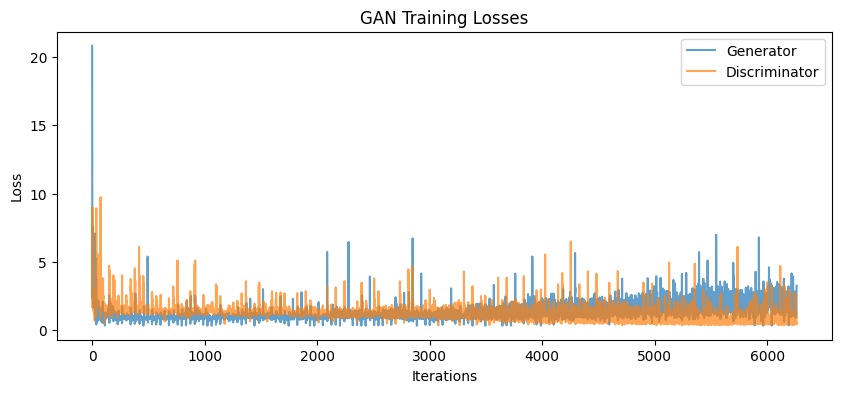

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator', alpha=0.7)
plt.plot(D_losses, label='Discriminator', alpha=0.7)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.show()